# Two layer feedback params
This looks at obtaining the feedback parameters in a two layer model. And then comparing a theoretical and actual effective heat capacity.

In [1]:
import copy
import sys
import os
import inspect

from sympy.abc import lamda

from isca_tools.plot.base import line_masked_lw
from isca_tools.thesis.adiabat_theory import get_z_ft_approx
from isca_tools.thesis.profile_fitting import get_tropopause_lev_ind
from isca_tools.thesis.surface_flux_taylor import name_square
from isca_tools.utils.fourier import coef_conversion
from isca_tools.utils.xarray import wrap_with_apply_ufunc, update_dim_slice, transpose_common_dims_like
from matplotlib.ticker import FuncFormatter, FixedLocator

# REMOTE - So can access functions in isca_tools which is in home/Isca directory
# sys.path.append(os.path.join(os.environ['HOME'], 'Isca'))
# LOCAL - So can access functions in isca_tools which is in StAndrews/Isca
sys.path.append(os.environ['PWD'])
import isca_tools
from isca_tools.utils.moist_physics import clausius_clapeyron_factor, sphum_sat, get_density
from isca_tools.utils.constants import kappa, L_v, c_p, c_p_water, rho_water, Stefan_Boltzmann, R, R_v, g
from isca_tools.utils import numerical
from isca_tools.utils.radiation import get_heat_capacity
from isca_tools.plot import colored_line, line_masked_lw
from isca_tools.thesis.surface_energy_budget_2layer import get_feedback_params
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from tqdm.notebook import tqdm
from isca_tools.plot import fig_resize, update_fontsize, update_linewidth, savefig, label_subplots

from jobs.thesis_season.thesis_figs.utils import get_fourier_fit_xr, polyfit_phase_xr
import jobs.thesis_season.column.utils as utils

# Use custom matplotlib style for publishing
plt.style.use('/Users/joshduffield/Documents/StAndrews/Isca/jobs/tau_sweep/aquaplanet/publish_figures/publish.mplstyle')
ax_linewidth = plt.rcParams['axes.linewidth']

In [63]:
# exp_name = [f"thesis_season/column/depth={i}/k=1_abs=0_2" for i in [5, 20]]
exp_name = [f"thesis_season/column/depth={i}/fix_rh" for i in [5, 20]]
ds_base = utils.load_ds(exp_name=exp_name, lat_min=30, var_keep=utils.var_keep + ['drag_q', 'olr'])
if 'rh_flux_q' not in ds_base.attrs:
    ds_base.attrs['rh_flux_q'] = 0.7
ds = utils.get_annual_zonal_mean(ds_base)
# Set temp_diseqb_r to one value for each lat, depth. But save raw original values
# ds = ds.rename({'temp_diseqb_r': 'temp_diseqb_r_raw'})
# ds['temp_diseqb_r'] = ds.temp_diseqb_r_raw*0 + ds.temp_diseqb_r_raw.median(dim='time')

  0%|          | 0/2 [00:00<?, ?it/s]

### LH calculation sanity check
In these simulations, I used the parameter `rh_flux_q` to fix the RH value used in the computation of latent heat. Below I confirm that the latent heat is that obtained using `rh_flux_q` and not the actual relative humidity.

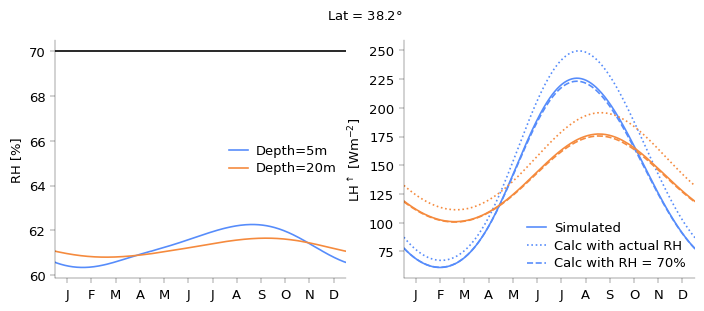

Actual RH, mean error: 7.96 W/m^2
Actual RH, max error: 24.59 W/m^2
Fixed RH, mean error: 0.43 W/m^2
Fixed RH, max error: 2.63 W/m^2


In [64]:
lat_ind_plot = 0

fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ax[0].plot(ds_base.rh_atm.isel(depth=i, lat=lat_ind_plot) * 100, color=f'C{i}', label=f'Depth={ds.depth[i]:.0f}m')
    ax[1].plot(ds_base.flux_lhe.isel(depth=i, lat=lat_ind_plot), color=f'C{i}', label='Simulated' if i == 0 else None)
    flux_calc = utils.get_flux(ds_base.isel(depth=i, lat=lat_ind_plot), 'lh', calc=True, use_rh_flux_q=False)
    ax[1].plot(flux_calc, color=f'C{i}', linestyle=':', label='Calc with actual RH' if i == 0 else None)
    flux_calc = utils.get_flux(ds_base.isel(depth=i, lat=lat_ind_plot), 'lh', calc=True, use_rh_flux_q=True)
    ax[1].plot(flux_calc, color=f'C{i}', linestyle='--',
               label=f'Calc with RH = {ds.rh_flux_q * 100:.0f}%' if i == 0 else None)
ax[0].axhline(ds.rh_flux_q * 100, color='k')
update_linewidth(fig)
ax[0].legend()
ax[1].legend()
fig.suptitle(f"Lat = {ds.lat[lat_ind_plot]:.1f}$\degree$")
update_fontsize(fig)
ax[0].set_xlim(0, 360)
# ax[1].set_ylim(0, 140)
ax[0].set_xticks(*utils.month_ticks)
ax[0].set_ylabel('RH [%]')
ax[1].set_ylabel('$\\text{LH}^{\\uparrow}$ [Wm$^{-2}$]')
plt.show()

flux_calc = [utils.get_flux(ds_base, 'lh', calc=True)]
ds_use = ds_base.copy(deep=True)
ds_use['rh_atm'] = ds_use['rh_atm'] * 0 + ds_use.rh_flux_q
flux_calc.append(utils.get_flux(ds_use, 'lh', calc=True))
print(f"Actual RH, mean error: {np.mean(np.abs(ds_base.flux_lhe - flux_calc[0])):.2f} W/m^2")
print(f"Actual RH, max error: {np.max(np.abs(ds_base.flux_lhe - flux_calc[0])):.2f} W/m^2")
print(f"Fixed RH, mean error: {np.mean(np.abs(ds_base.flux_lhe - flux_calc[1])):.2f} W/m^2")
print(f"Fixed RH, max error: {np.max(np.abs(ds_base.flux_lhe - flux_calc[1])):.2f} W/m^2")

### Radiative temperature
In the two layer model, there is a radiative temperature which is the temperature that an isothermal atmosphere radiates to space and to the surface. Below we see that this computed $T_r$ is simply related to the lowest model level temperature $T_a$ through a simple subtraction of temperature, but no phase shift is required.

In contrast, we also see that $T_s$ is out of phase with $T_r$ so no simple relationship.

I compute two radiative temperatures, one for emission to surface, one for emission to space. Not surprisingly the emission to space is colder. The linear relationship for the latter is also significantly worse. But there does not seem to be a significant phase difference as is shown when expressing in terms of $T_s$.

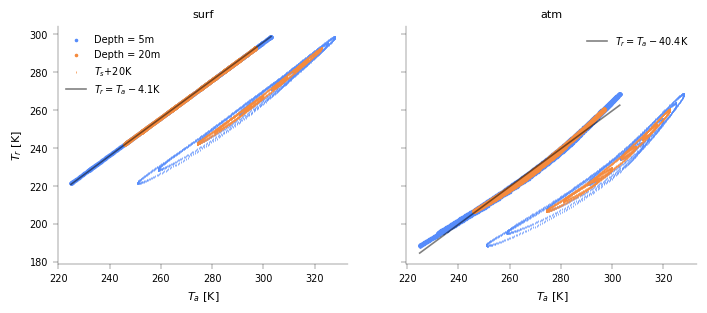

In [65]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
for j, key in enumerate(['surf', 'atm']):
    ax[j].set_xlabel('$T_a$ [K]')
    ax[j].set_title(key)
    for i in range(ds.depth.size):
        ax[j].scatter(ds.temp_atm.isel(depth=i), ds[f"temp_rad_{key}"].isel(depth=i), color=f"C{i}", marker='.', s=10,
                      label=f'Depth = {ds.depth[i]:.0f}m' if j == 0 else None)
        ax[j].scatter(ds.temp_surf.isel(depth=i) + 20, ds[f"temp_rad_{key}"].isel(depth=i), color=f"C{i}",
                      marker='|', s=1, label='$T_s$+20K' if i == 1 and j == 0 else None)

    var = float(ds[f"temp_diseqb_{key}"].median())
    ax[j].plot([ds.temp_atm.min(), ds.temp_atm.max()], np.asarray([ds.temp_atm.min(), ds.temp_atm.max()]) - var,
               color='k', alpha=0.5, label=f"$T_r=T_a - {var:.1f}$K")
update_linewidth(fig)
ax[0].legend()
ax[1].legend()
ax[0].set_ylabel('$T_r$ [K]')
plt.show()

#### $T_{dqr}$
Above it seems that a single shift of around 40K for relating $T_{ra}$ and $T_a$ works for all latitudes and both mixed layer depths. However, below we show the mean for each lat and depth - we will use this going foreward and treat each separately. We also plot the IQR to emphasize that there is little variation in $T_{dqr}$ across the year, as expect from the linear relationship shown above.

In the plot below this, we show that in general for emission to surface, the hotter it gets, the colder the emission temperature relative to the lowest model level. While for emission to space, the relationship is more complicated and not simple link between radiative temperature and lowest model level. Maybe expected as what governs lapse rate becomes important.

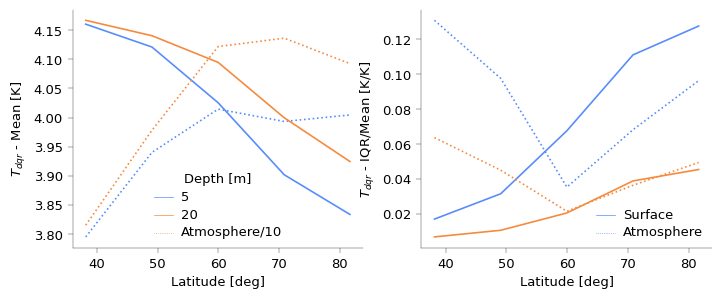

In [66]:
fig, ax = plt.subplots(1, 2, sharex=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ax[0].plot(ds.lat, ds.temp_diseqb_surf.isel(depth=i).mean(dim='time'), label=f'{ds.depth[i]:.0f}', color=f"C{i}")
    ax[0].plot(ds.lat, ds.temp_diseqb_atm.isel(depth=i).mean(dim='time') / 10, linestyle=':', color=f"C{i}",
               label='Atmosphere/10' if i == 1 else None)
    ax[1].plot(ds.lat, ((ds.temp_diseqb_surf.quantile(0.75, dim='time') - ds.temp_diseqb_surf.quantile(0.25, dim='time')
                         ) / ds.temp_diseqb_surf.mean(dim='time')
                        ).isel(depth=i), label='Surface' if i == 0 else None, color=f"C{i}")
    ax[1].plot(ds.lat, ((ds.temp_diseqb_atm.quantile(0.75, dim='time') - ds.temp_diseqb_atm.quantile(0.25, dim='time')
                         ) / ds.temp_diseqb_atm.mean(dim='time')
                        ).isel(depth=i), label='Atmosphere' if i == 0 else None, linestyle=':', color=f"C{i}")
    ax[i].set_xlabel(utils.label_lat)
ax[0].legend(title='Depth [m]')
ax[1].legend()
ax[0].set_ylabel('$T_{dqr}$ - Mean [K]')
ax[1].set_ylabel('$T_{dqr}$ - IQR/Mean [K/K]')
update_fontsize(fig)
update_linewidth(fig)
plt.show()

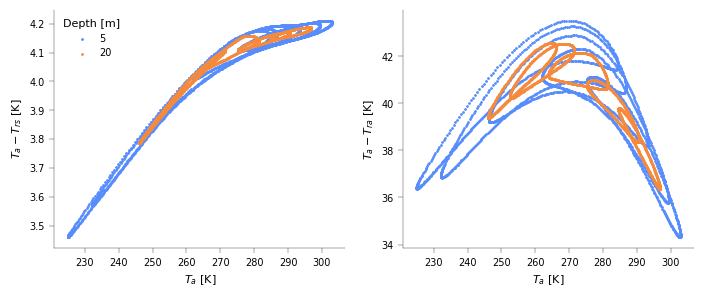

In [67]:
fig, ax = plt.subplots(1, 2, sharex=True, sharey=False)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ax[0].scatter(ds.temp_atm.isel(depth=i), ds.temp_diseqb_surf.isel(depth=i), s=1, label=f'{ds.depth[i]:.0f}',
                  color=f"C{i}")
    ax[1].scatter(ds.temp_atm.isel(depth=i), ds.temp_diseqb_atm.isel(depth=i), s=1)
ax[0].legend(title='Depth [m]')
ax[0].set_ylabel('$T_a - T_{rs}$ [K]')
ax[1].set_ylabel('$T_a - T_{ra}$ [K]')
ax[0].set_xlabel('$T_a$ [K]')
ax[1].set_xlabel('$T_a$ [K]')
plt.show()

#### Empirical fitting of $T{dqr}$
Below I fit the $T_a-T_r$ as a function of $T_a$. This provides an important amendment in cases where the coefficient is greater magnitude than 0.1. I force the fitting with an intercept of zero.

In [68]:
temp_diseqb_fit_coef = {}
for key in ['surf', 'atm']:
    # Force zero intercept as goes through mean
    temp_diseqb_fit_coef[key] = polyfit_phase_xr(ds.temp_atm - ds.temp_atm.mean(dim='time'),
                                                 ds[f'temp_diseqb_{key}'] - ds[f'temp_diseqb_{key}'].mean(dim='time'),
                                                 1, include_phase=False, coef_fix=[None, None, 0]).sel(deg='1')
    # Below I take account of phase shift but more complicated and makes little difference
    # var = polyfit_phase_xr(ds.temp_atm - ds.temp_atm.mean(dim='time'),
    #                                              ds[f'temp_diseqb_{key}'] - ds[f'temp_diseqb_{key}'].mean(dim='time'),
    #                                              1, include_phase=True, coef_fix=[None, None, 0])
    # temp_diseqb_fit_coef[key] = coef_conversion(amp_coef=var.sel(deg='1'), phase_coef=var.sel(deg='phase'))[0]


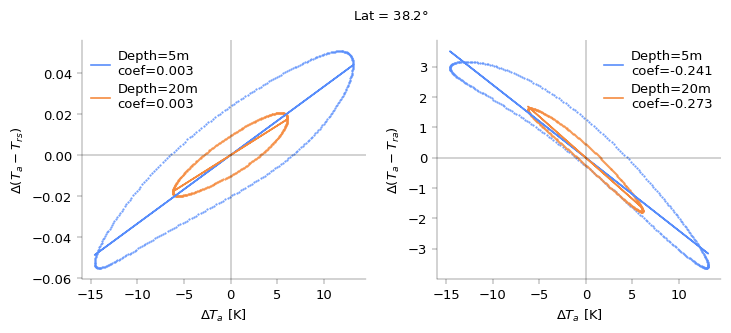

In [69]:
lat_ind_plot = 0

fig, ax = plt.subplots(1, 2, sharex=True, sharey=False)
fig_resize(fig, utils.width['two_col'] * 1.5)
var = (ds.temp_atm - ds.temp_atm.mean(dim='time')).isel(lat=lat_ind_plot)
for i in range(ds.depth.size):
    for j, key in enumerate(['surf', 'atm']):
        ax[j].scatter(var.isel(depth=i),
                      (ds[f'temp_diseqb_{key}'] - ds[f'temp_diseqb_{key}'].mean(dim='time')).isel(lat=lat_ind_plot,
                                                                                                  depth=i),
                      s=1, color=f"C{i}", marker='.')
        ax[j].plot(var.isel(depth=i), temp_diseqb_fit_coef[key].isel(depth=i, lat=lat_ind_plot) * var.isel(depth=i),
                   color=f"C{i}",
                   label=f"Depth={ds.depth[i]:.0f}m\ncoef={temp_diseqb_fit_coef[key].isel(depth=i, lat=lat_ind_plot):.3f}")
update_linewidth(fig)
for ax_use in ax:
    ax_use.axhline(0, color='k', lw=ax_linewidth)
    ax_use.axvline(0, color='k', lw=ax_linewidth)
ax[0].legend()
ax[1].legend()
ax[0].set_ylabel('$\\Delta (T_a - T_{rs})$')
ax[1].set_ylabel('$\\Delta (T_a - T_{ra})$')
ax[0].set_xlabel('$\\Delta T_a$ [K]')
ax[1].set_xlabel('$\\Delta T_a$ [K]')
fig.suptitle(f"Lat = {ds.lat[lat_ind_plot]:.1f}$\degree$")
update_fontsize(fig)
fig.subplots_adjust(wspace=0.25)
plt.show()

### Taylor Series Reconstruction of Fluxes
Below, I reconstruct the latent, sensible heat fluxes as well as net longwave radiation absorbed by the atmosphere. We see that as well as $T_a$, and $T_s$; we also require $T_{dqr}=T_a-T_r$ to accurately capture the seasonal cycle of longwave. But as shown in the scatter plot below this, this does not show an obvious relation to $T_a$, and is probably also a function of optical depth.

For the most part though, the linear combination of $T_s$ and $T_a$ effects dominate the variation in the fluxes.

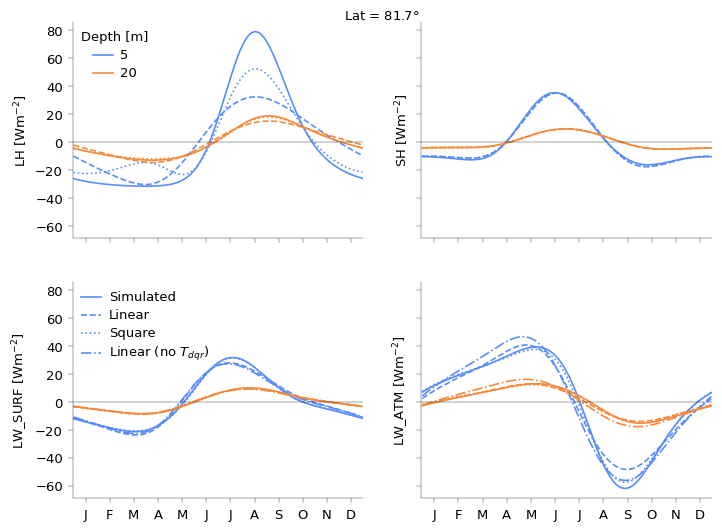

In [70]:
lat_ind_plot = -1
use_temp_diseqb_fit = True  # If True, will link the diseqb temperature to temp_atm, rather than use actual value

fig, ax = plt.subplots(2, 2, sharex=True, sharey=True)
fig_resize(fig, utils.width['two_col'] * 1.5)
ax = ax.flatten()

for i, key in enumerate(['lh', 'sh', 'lw_surf', 'lw_atm']):
    if use_temp_diseqb_fit:
        ds_use = ds.isel(lat=lat_ind_plot).copy(deep=True)
        for key2 in ['surf', 'atm']:
            ds_use[f'temp_diseqb_{key2}'] = ds_use[f'temp_diseqb_{key2}'].mean(dim='time') + \
                                            temp_diseqb_fit_coef[key2].isel(lat=lat_ind_plot) * (
                                                        ds_use.temp_atm - ds_use.temp_atm.mean(dim='time'))
    else:
        ds_use = ds.isel(lat=lat_ind_plot)
    var = utils.get_flux(ds.isel(lat=lat_ind_plot), key)
    var2 = utils.reconstruct_flux_xr(ds_use,
                                     ds_use.mean(dim='time', keep_attrs=True),
                                     key, use_rh_flux_q=True)
    ax[i].set_ylabel(key.upper() + " [Wm$^{-2}$]")
    for j in range(ds.depth.size):
        ax[i].plot(ds.time, (var - var.mean(dim='time')).isel(depth=j), color=f'C{j}',
                   label='Simulated' if i == 2 and j == 0 else f'{ds.depth[j]:.0f}' if i == 0 else None)
        for k in range(2):
            ax[i].plot(ds.time, var2[k + 1].isel(depth=j) - var2[k + 1].isel(depth=j).mean(dim='time'), color=f'C{j}',
                       linestyle=['--', ':'][k], label=['Linear', 'Square'][k] if j == 0 and i == 2 else None)
        if 'lw' in key:
            var3 = var2[-1]['temp_surf'] + var2[-1]['temp_atm']
            ax[i].plot(ds.time, (var3 - var3.mean(dim='time')).isel(depth=j), color=f'C{j}', linestyle='-.',
                       label='Linear (no $T_{dqr}$)' if j == 0 else None)
update_linewidth(fig)
for i in range(len(ax)):
    ax[i].axhline(0, color='k', lw=ax_linewidth)
ax[0].legend(title='Depth [m]')
ax[2].legend()
ax[0].set_xlim(-1, 360)
ax[0].set_xticks(*utils.month_ticks)
fig.suptitle(f"Lat = {ds.lat[lat_ind_plot]:.1f}$\degree$", y=0.9)
update_fontsize(fig)
var = utils.get_flux(ds.isel(lat=lat_ind_plot), 'lw_sfc', calc=True)
# ax[2].plot(ds.time, (var-var.mean(dim='time')).isel(depth=0), color='k')
plt.show()

## $C_{\text{eff}}$ and $\lambda_{\text{eff}}$
Using the Taylor series coefficients and empirical fitting for $T_a-T_{ra}$ and $T_a-T_{rs}$, we find the $\lambda$ parameters required for a theoretical estimate of $C_{\text{eff}}$ and $\lambda_{\text{eff}}$. We show that below.

We get a decent theoretical estimate, for which we use the dry heat capacity of the entire atmosphere, $c_pp_s/g$.

In [71]:
ds_use = ds.mean(dim='time', keep_attrs=True)
arg_names = list(inspect.signature(get_feedback_params).parameters.keys())
args_use = {key: ds_use[key] for key in arg_names if key in ds_use}
args_use['rh_atm'] = ds_use.rh_flux_q
args_use['drag_coef'] = ds_use.drag_coef
args_use['temp_diseqb_surf_coef'] = temp_diseqb_fit_coef['surf']
args_use['temp_diseqb_atm_coef'] = temp_diseqb_fit_coef['atm']
lambda_s1, lambda_s2, lambda_a1, lambda_a2 = get_feedback_params(**args_use)

In [72]:
_, coef_amp, coef_phase = get_fourier_fit_xr(ds.time, ds.temp_surf, n_harmonics=1, pad_coefs_phase=True)
_, coef_sw_amp, coef_sw_phase = get_fourier_fit_xr(ds.time, ds.swdn_sfc, n_harmonics=1, pad_coefs_phase=True)
coef_amp = np.abs(coef_amp.sel(harmonic=1))
coef_phase = coef_phase.sel(harmonic=1)
coef_sw_amp = np.abs(coef_sw_amp.sel(harmonic=1))

In [73]:
f = 1 / (ds.time.size * utils.day_seconds)
ds['depth_eff'] = get_heat_capacity(c_p_water, rho_water, coef_sw_amp * np.sin(coef_phase) / (2 * np.pi * f) / coef_amp,
                                    True) / ds.depth
ds['lambda_eff'] = coef_sw_amp * np.cos(coef_phase) / coef_amp

In [74]:

# var = (ds.depth_eff - 1) * (lambda_a2**2/lambda_s2/lambda_a1)
# heat_cap_atmos = var * ds.heat_capacity

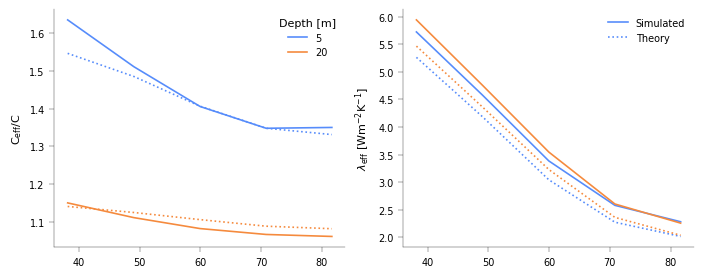

In [90]:
heat_cap_atmos = c_p * (float(ds.p_surf.max()-200*100)) / g * (1-temp_diseqb_fit_coef['atm'])
# print(f"Heat capacity of atmosphere = {get_heat_capacity(c_p_water, rho_water, heat_cap_atmos, True):.1f}m")
var_const = lambda_s2 * lambda_a2 / (lambda_a2 ** 2 + (2 * np.pi * f * heat_cap_atmos) ** 2)
lambda_eff_theory = lambda_s1 - var_const * lambda_a1
# var_const2 = lambda_s2 * lambda_a2 / lambda_a2 ** 2
depth_eff_theory = 1 + var_const * heat_cap_atmos / ds.heat_capacity
# var_const2 = lambda_s2 * lambda_a2 / lambda_a2 ** 2
# heat_cap_atmos_eff = (ds.depth_eff - 1)/var_const2 * ds.heat_capacity
# depth_eff_theory = 1 + var_const2 * heat_cap_atmos_eff / ds.heat_capacity

fig, ax = plt.subplots(1, 2, sharex=True, sharey=False)
fig_resize(fig, utils.width['two_col'] * 1.5)
for i in range(ds.depth.size):
    ax[0].plot(ds.lat, ds.depth_eff.isel(depth=i), color=f'C{i}', label=f'{ds.depth[i]:.0f}')
    ax[0].plot(ds.lat, depth_eff_theory.isel(depth=i), color=f'C{i}', linestyle=':')
    ax[1].plot(ds.lat, ds.lambda_eff.isel(depth=i), color=f'C{i}', label='Simulated' if i == 0 else None)
    ax[1].plot(ds.lat, lambda_eff_theory.isel(depth=i), color=f'C{i}', linestyle=':',
               label='Theory' if i == 0 else None)
update_linewidth(fig)
ax[0].legend(title='Depth [m]')
ax[1].legend()
update_linewidth(fig)
ax[0].set_ylabel("C$_{\\text{eff}}/$C")
ax[1].set_ylabel("$\lambda_{\\text{eff}}$ [Wm$^{-2}\\text{K}^{-1}$]")
plt.show()

### Heat capacity of atmosphere
I am slightly unsure of what to use as heat capacity of the atmosphere. Below I show the implied value, given the effective heat capacity and our empirically found feedback parameters. Maybe as expected, it decreases at higher latitudes where it is colder.

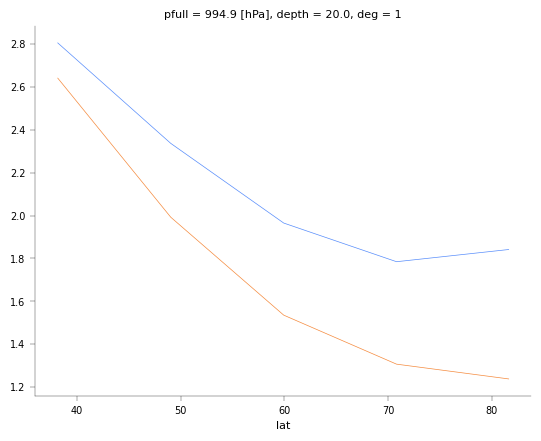

In [76]:
var_const2 = lambda_s2 * lambda_a2 / lambda_a2 ** 2
((ds.depth_eff - 1)/var_const2 * ds.depth).isel(depth=0).plot()
((ds.depth_eff - 1)/var_const2 * ds.depth).isel(depth=1).plot()

In [77]:
ds_lev = isca_tools.load_dataset(exp_name[0])[['temp']].sel(lat=ds.lat.values)
ds_lev = utils.get_annual_zonal_mean(ds_lev).load()

/Users/joshduffield/Documents/StAndrews/Isca/isca_tools/utils/load.py:63: UserWarning: First month saved is 121 not 1.
  warnings.warn(f'First month saved is {first_month} not 1.')


In [78]:
ds_lev['z'] = get_z_ft_approx(ds_lev.temp.isel(pfull=-1), ds_lev.temp, ds_lev.pfull[-1]*100, ds_lev.pfull*100)

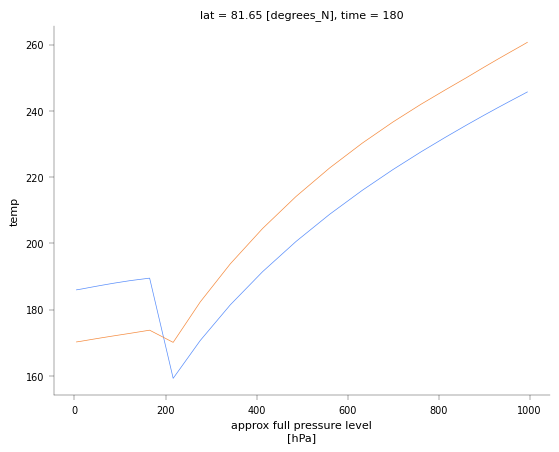

In [79]:
ds_lev.temp.isel(lat=-1, time=0).plot()
ds_lev.temp.isel(lat=-1, time=180).plot()
# ds_lev.temp.mean(dim='time').isel(lat=1).plot()
# ds_lev.temp.mean(dim='time').isel(lat=-1).plot()